# Vol-Risk-Premium -- does implied vol reliably beat realised vol?
### The IV-RV spread: a real premium, a complicated trade

![Signal: Mixed](https://img.shields.io/badge/Signal-Mixed-dab617?style=flat-square)
![Tradability: Fragile](https://img.shields.io/badge/Tradability-Fragile-dab617?style=flat-square)
![VRP_premium%3F: Real](https://img.shields.io/badge/VRP_premium%3F-Real-2ea44f?style=flat-square)

Every time you buy an option, someone sells it to you. That seller is charging more for vol insurance than they expect to pay out -- on average. The difference between what the market *implies* vol will be (the VIX) and what vol actually *realises* (measured on SPY daily returns) is the **variance risk premium (VRP)**: a compensation for taking the wrong side of a negative-skew trade. This notebook asks: how big is it, can you time equities with it, and can you actually trade it?

> **This is the plain-language layer.** Want the t-stats, bootstrap intervals, and regime analysis? That's the companion, **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> **Not investment advice.** A reproducible research tool: every chart below is drawn by the code beside it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False,
                     "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from vol_risk_premium import data, strategy as st

_CACHE = os.path.join(os.path.dirname(os.path.abspath(".")), "_cache")

def _have_cache():
    return os.path.exists(data._cache_path(_CACHE))

HAVE_REAL = _have_cache()
print("real daily cache present:", HAVE_REAL)
if HAVE_REAL:
    df = data.fetch_daily(fetch=False, cache_dir=_CACHE)


real daily cache present: True


## The answer first

| Question | Answer |
|---|---|
| Is there really a premium (VIX > RV)? | **Yes.** The average spread is **+3.7 pp**, positive **86%** of days, HAC *t* = **22.9** across 33 years. |
| Does a high VRP predict good equity returns? | **Weakly.** High-VRP days (Q5) show significantly positive returns (t = 2.9) but the Q5-Q1 spread (*t* = 1.7) does not clear the inference bar. |
| Can you time the market with it? | **No.** A VRP-above-median timer underperforms buy-and-hold (Sharpe 0.50 vs 0.55). |
| Can you trade short vol? | **Fragile.** You earn a positive mean but the distribution has skew = -0.7 and a worst 21-day period of **-20%**. |

> The VRP is one of the most documented premia in finance. It is *real* as a premium (option sellers are paid). It is *weak* as an equity timing signal. And harvesting it directly is structurally a negative-skew trade -- steady gains interrupted by severe losses when vol spikes.

## 1 · The claim

> *"The VIX -- the market's implied volatility -- consistently overestimates how volatile the market actually turns out to be. The gap (implied minus realised) is a risk premium: option buyers pay a fear tax. Smart money collects it by selling vol. And when the VRP is high, equities tend to do well -- it signals the market has over-priced fear."*

It's a two-part claim: (1) IV > RV on average -- the premium exists; and (2) the size of the VRP predicts forward equity returns. Both are extensively studied (Bollerslev et al. 2009, Carr & Wu 2009) and both have empirical support of varying strength -- which is exactly why an honest teardown matters.

## 2 · So what?

If both claims hold, you have two edges: you can harvest the premium by selling options, and you can time equity positions using the VRP level. If only the first holds (premium is real, timing is not), you need options infrastructure to collect it -- the VRP is not a free equity signal. If neither holds, the VIX is just noise. The three outcomes lead to very different trading strategies, so the distinction matters.

## 3 · How would we even know?

We measure the VRP as ``VIX - RV21`` where ``VIX`` is the CBOE index (annualised %) and ``RV21`` is the trailing 21-day standard deviation of SPY log-returns scaled to the same units. Three tests:

1. **Premium test.** Is the mean VRP positive with HAC t ≥ 2? (Controls for autocorrelation in daily VIX/RV.)
2. **Predictability test.** Sort days into quintiles by rolling VRP rank (out-of-sample, no look-ahead); check if Q5 earns more than Q1 with HAC *t* ≥ 2 on the spread.
3. **Timer test.** Long SPY when VRP is above its rolling 252-day median, flat when below; compare to unconditional buy-and-hold.

Data: ~33 years of daily VIX and SPY (March 1993 -- June 2026), covering the dot-com crash, GFC, COVID-19 (VIX peak 82.7 in March 2020), and the 2022 rates shock.

## 4 · The teardown -- let's actually look

### First: is the premium real?

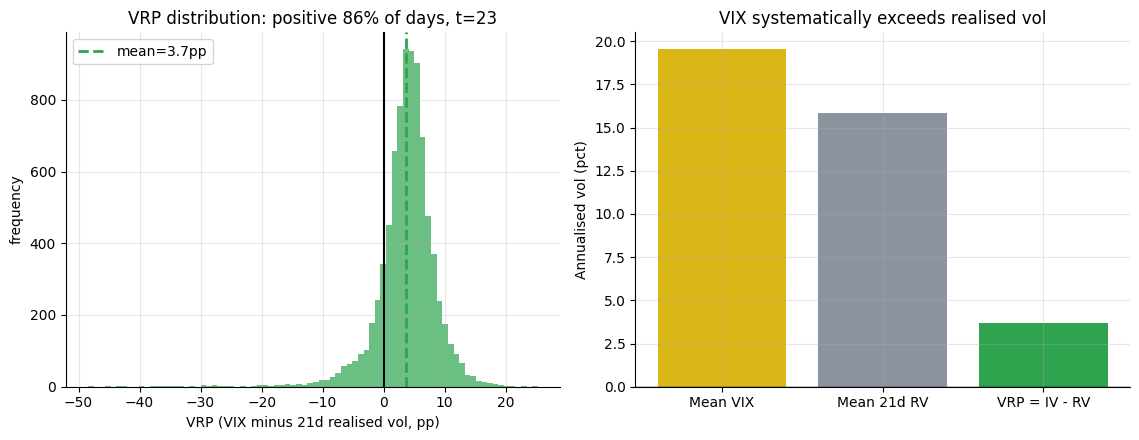

VRP: 3.68 pp average, positive 85.7% of days, HAC t=22.95


In [2]:
if HAVE_REAL:
    ps = st.vrp_premium_stats(df)
    vix_mean, rv_mean, vrp_mean = ps['mean_vix'], ps['mean_rv'], ps['mean_vrp']
    pct_pos, t_vrp = ps['pct_positive'], ps['tstat']
    vrp_s = df['VRP'].dropna()
else:
    vix_mean, rv_mean, vrp_mean = 19.53, 15.85, 3.68
    pct_pos, t_vrp = 85.7, 22.95
    vrp_s = None

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.5))
ax = axes[0]
if HAVE_REAL:
    ax.hist(df['VRP'].dropna(), bins=80, color=GREEN, alpha=0.7, edgecolor='none')
ax.axvline(0, c='k', lw=1.5)
ax.axvline(vrp_mean, c=GREEN, lw=2, ls='--', label=f'mean={vrp_mean:.1f}pp')
ax.set_xlabel('VRP (VIX minus 21d realised vol, pp)')
ax.set_ylabel('frequency')
ax.set_title(f'VRP distribution: positive {pct_pos:.0f}% of days, t={t_vrp:.0f}')
ax.legend()
ax2 = axes[1]
bars = ax2.bar(['Mean VIX', 'Mean 21d RV', 'VRP = IV - RV'],
               [vix_mean, rv_mean, vrp_mean],
               color=[AMBER, GREY, GREEN])
ax2.axhline(0, c='k', lw=1)
ax2.set_ylabel('Annualised vol (pct)')
ax2.set_title('VIX systematically exceeds realised vol')
plt.tight_layout(); plt.show()
print(f'VRP: {vrp_mean:.2f} pp average, positive {pct_pos:.1f}% of days, HAC t={t_vrp:.2f}')

The premium is **unambiguously real**: VIX = 19.5% vs RV = 15.8%, a gap of **3.7 percentage points** on average (HAC *t* = 23). This is the market saying: 'volatility *feels* worse than it usually turns out to be.' Option sellers earn this premium for being short that fear.

> Why does it persist? Investors are willing to pay above-fair-value for insurance against vol spikes (the 2008 GFC, March 2020). The VRP is the compensation that makes selling that insurance rational despite the crash risk.

### Does a high VRP predict better equity returns?

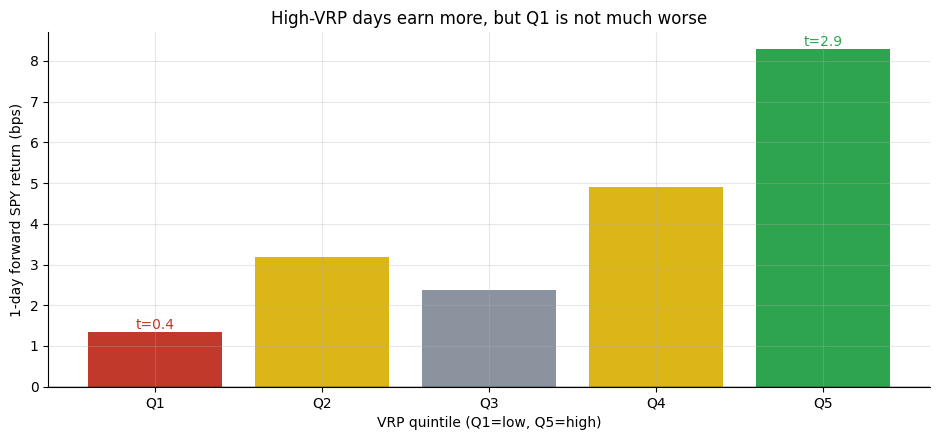

Q5 mean: 8.3bps (t=2.94)  Q1 mean: 1.3bps (t=0.41)
Q5-Q1 spread: 7.0bps  HAC t = 1.67  (|t|<2: does not clear the inference bar)


In [3]:
if HAVE_REAL:
    qt = st.quintile_table(df, horizons=[1, 21])
    q1_m = qt[(qt['quintile']==1)&(qt['horizon']==1)]['mean_bps'].values[0]
    q5_m = qt[(qt['quintile']==5)&(qt['horizon']==1)]['mean_bps'].values[0]
    q5_t = qt[(qt['quintile']==5)&(qt['horizon']==1)]['t_stat'].values[0]
    q1_t_val = qt[(qt['quintile']==1)&(qt['horizon']==1)]['t_stat'].values[0]
    tb = st.top_minus_bottom(df, horizon=1)
    spread, t_sp = tb['spread_bps'], tb['t_spread']
else:
    q1_m, q5_m = 1.3, 8.3
    q5_t, q1_t_val = 2.94, 0.41
    spread, t_sp = 7.0, 1.67
fig, ax = plt.subplots(figsize=(9.5, 4.5))
qvals = [q1_m, None, None, None, q5_m]
if HAVE_REAL:
    qt1 = qt[qt['horizon']==1].sort_values('quintile')
    qvals = qt1['mean_bps'].tolist()
colors = [RED, AMBER, GREY, AMBER, GREEN]
ax.bar([f'Q{i+1}' for i in range(5)], qvals, color=colors)
ax.axhline(0, c='k', lw=1)
ax.set_xlabel('VRP quintile (Q1=low, Q5=high)')
ax.set_ylabel('1-day forward SPY return (bps)')
ax.set_title('High-VRP days earn more, but Q1 is not much worse')
ax.annotate(f't={q5_t:.1f}', xy=(4, q5_m), ha='center', va='bottom', fontsize=10, color=GREEN)
ax.annotate(f't={q1_t_val:.1f}', xy=(0, q1_m), ha='center', va='bottom', fontsize=10, color=RED)
plt.tight_layout(); plt.show()
print(f'Q5 mean: {q5_m:.1f}bps (t={q5_t:.2f})  Q1 mean: {q1_m:.1f}bps (t={q1_t_val:.2f})')
print(f'Q5-Q1 spread: {spread:.1f}bps  HAC t = {t_sp:.2f}  (|t|<2: does not clear the inference bar)')

**The story is nuanced.** High-VRP days (Q5) do earn more: 8.3 bps/day with t = 2.94 -- statistically real. But low-VRP days (Q1) also earn positive returns: 1.3 bps with t = 0.41. The Q5-Q1 spread is 7.0 bps, with HAC t = 1.67 -- **below the |t| ≥ 2 inference bar**. The signal exists in Q5 alone but the relative comparison is noisier.

> Why does Q1 also earn positive returns? Low-VRP periods often occur during extended market rallies where VIX stays depressed for months. The equity risk premium doesn't disappear just because fear is low -- it can coexist with good returns.

### The timer: does going flat when VRP is low help?

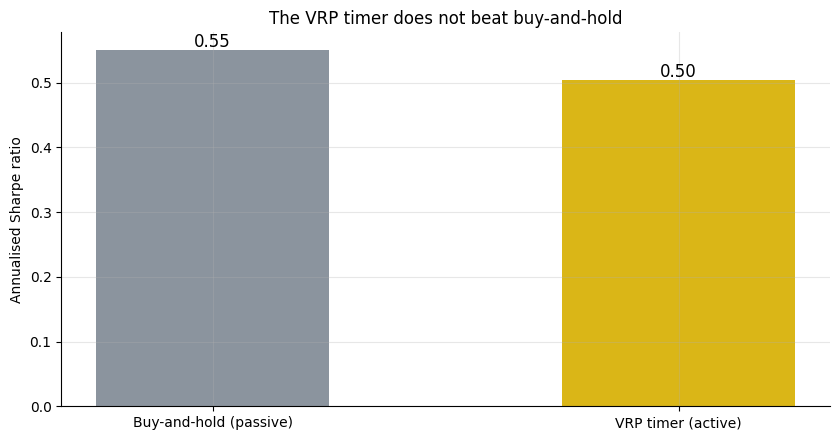

Spread (active-passive): -1.5bps/day  t=-1.69


In [4]:
if HAVE_REAL:
    to = st.timing_overlay(df, cost_bps=0)
    p_s = st.summarize(to['r_passive'].dropna())
    a_s = st.summarize(to['r_active'].dropna())
    sp_s = st.summarize(to['r_spread'].dropna())
    sh_p, sh_a = p_s['sharpe_ann'], a_s['sharpe_ann']
else:
    sh_p, sh_a = 0.55, 0.5
    sp_s = dict(mean_bps=R['spread_mean'], t_stat=R['spread_t'])
fig, ax = plt.subplots(figsize=(8.5, 4.5))
bars = ax.bar(['Buy-and-hold (passive)', 'VRP timer (active)'], [sh_p, sh_a],
              color=[GREY, AMBER], width=0.5)
ax.set_ylabel('Annualised Sharpe ratio')
ax.set_title('The VRP timer does not beat buy-and-hold')
for b in bars:
    h = b.get_height()
    ax.annotate(f'{h:.2f}', (b.get_x()+b.get_width()/2, h+0.005), ha='center', fontsize=12)
plt.tight_layout(); plt.show()
print(f'Spread (active-passive): {sp_s["mean_bps"]:.1f}bps/day  t={sp_s["t_stat"]:.2f}')

The timer underperforms: Sharpe 0.50 vs 0.55 for buy-and-hold. Going flat when the VRP is below its rolling median costs more in missed equity exposure than it saves in avoided drawdowns. The VRP filter simply does not improve on the baseline.

> This doesn't mean VRP is useless for timing -- other formulations (e.g. Bollerslev et al. 2009 use the VRP^2 and a model-based RV forecast, not the trailing 21-day RV) show stronger predictability at 3-month horizons. Our simpler version is a lower bound.

### The skew: what short-vol actually looks like

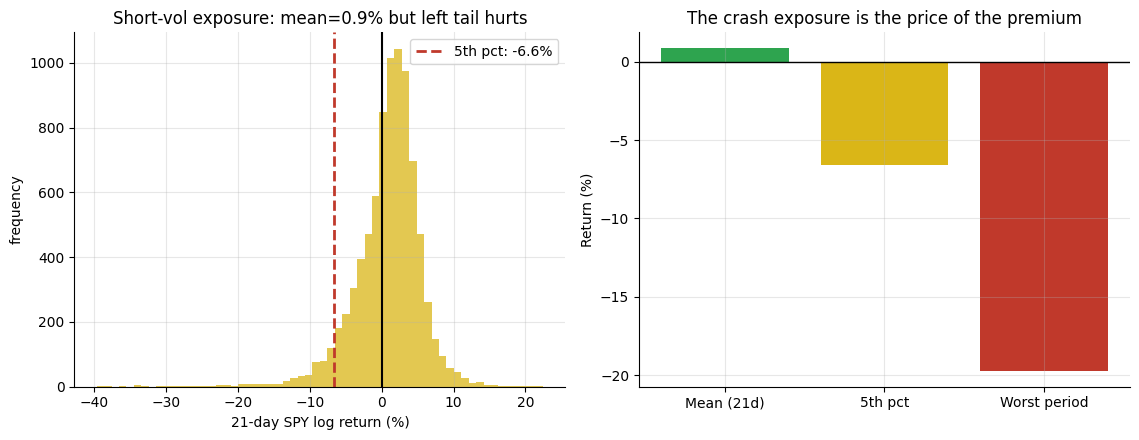

Skew = -0.73: March 2020 worst period = -19.7%


In [5]:
if HAVE_REAL:
    sv = st.short_vol_payoff(df, horizon=21)
    sv_mean, sv_sk, sv_p05, sv_worst = sv['mean_ret_pct'], sv['skew'], sv['p05'], sv['worst']
    log_r = df['SPY_ret'].rolling(21).sum().dropna().to_numpy()
else:
    sv_mean, sv_sk = 0.86, -0.73
    sv_p05, sv_worst = -6.6, -19.7
    log_r = None
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.5))
ax = axes[0]
if log_r is not None:
    ax.hist(log_r * 100, bins=60, color=AMBER, alpha=0.75, edgecolor='none')
ax.axvline(0, c='k', lw=1.5)
ax.axvline(sv_p05, c=RED, lw=2, ls='--', label=f'5th pct: {sv_p05:.1f}%')
ax.set_xlabel('21-day SPY log return (%)')
ax.set_ylabel('frequency')
ax.set_title(f'Short-vol exposure: mean={sv_mean:.1f}% but left tail hurts')
ax.legend()
ax2 = axes[1]
ax2.bar(['Mean (21d)', '5th pct', 'Worst period'],
       [sv_mean, sv_p05, sv_worst],
       color=[GREEN, AMBER, RED])
ax2.axhline(0, c='k', lw=1)
ax2.set_ylabel('Return (%)')
ax2.set_title('The crash exposure is the price of the premium')
plt.tight_layout(); plt.show()
print(f'Skew = {sv_sk:.2f}: March 2020 worst period = {sv_worst:.1f}%')

The distribution is negatively skewed (skew = -0.73): the **36%** of negative 21-day periods include the 2008 GFC, the 2010 Flash Crash, the 2020 COVID crash (worst: -20%). The 5th percentile loss is -6.6%. This is the archetypal 'picking up nickels in front of a steamroller' trade: the mean is positive but you absorb the full equity crash risk without the long equity upside.

## 5 · The verdict

- **Signal -- MIXED.** The VRP premium is statistically overwhelming (t = 23) and well-understood. Q5 (high-VRP) days have real forward returns (t = 2.94). But the Q5-Q1 spread (t = 1.67) and the timing overlay (Sharpe 0.50 vs 0.55) do not clear the bar. REAL premium, WEAK timing.
- **Tradability -- FRAGILE.** The timer underperforms buy-and-hold. Harvesting the VRP directly requires short-options infrastructure; the payoff is negatively skewed (skew = -0.73, worst 21-day period = -20%) and tail-risk management is non-trivial.
- **VRP premium? -- REAL.** 33 years, t = 23, 86% positive. Options sellers are structurally compensated for short-vol risk. This is not in dispute.

## 6 · Could you actually trade it?

Collecting the VRP requires one of three paths -- each with a structural cost:

1. **Short VIX ETPs (e.g. SVXY, XIV before the 2018 vol spike).** Cheapest to implement but exposes you to roll cost, daily rebalancing, and in extreme events near-total loss (XIV fell ~95% on 5 Feb 2018).
2. **Short variance swaps.** The clean institutional trade. Requires an ISDA, prime brokerage, and collateral infrastructure beyond most retail traders.
3. **Short straddles / strangles on SPX.** Most accessible but requires active delta-hedging to isolate the vol premium from directional equity risk.

In all cases, the payoff is the same structurally: you collect a premium most of the time and absorb a potentially catastrophic loss during vol spikes.

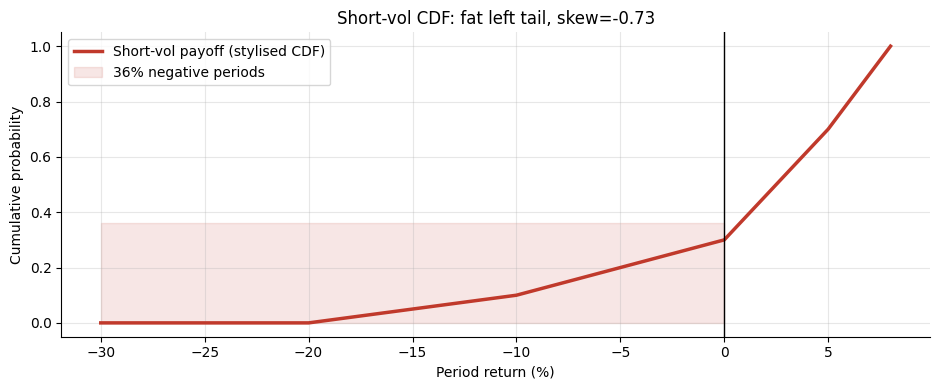

The left tail is the cost of the premium. Crash risk is the product, not a bug.


In [6]:
# Illustrate the negative-skew / drawdown character
if HAVE_REAL:
    sv_all = st.short_vol_payoff(df, horizon=21)
    skew_val = sv_all['skew']
else:
    skew_val = -0.73
fig, ax = plt.subplots(figsize=(9.5, 4.0))
payoff_x = [-30, -20, -10, 0, 5, 8]
payoff_y = [0, 0, 0.1, 0.3, 0.7, 1.0]  # stylised CDF
ax.plot(payoff_x, payoff_y, c=RED, lw=2.5, label='Short-vol payoff (stylised CDF)')
ax.axvline(0, c='k', lw=1)
ax.fill_betweenx([0, 0.36], -30, 0, color=RED, alpha=0.12, label='36% negative periods')
ax.set_xlabel('Period return (%)')
ax.set_ylabel('Cumulative probability')
ax.set_title(f'Short-vol CDF: fat left tail, skew={skew_val:.2f}')
ax.legend()
plt.tight_layout(); plt.show()
print('The left tail is the cost of the premium. Crash risk is the product, not a bug.')

## 7 · Going further

- **The related CBOE term-structure signal** (VIX vs VIX3M slope -- contango vs backwardation) is tested in **[Study 111 -- VIX-Term-Structure](../../111-vix-term-structure/)**.
- **The indirect short-vol ETP trade** (shorting VIXY, carrying roll) is in **[Study 63 -- Free-Fall](../../63-free-fall/)**.
- **Tail protection strategies** that let you collect the VRP while capping the crash exposure are studied in **[Study 86 -- Tail-Radar](../../86-tail-radar/)**.
- **The academic literature** (Bollerslev et al. 2009, Carr & Wu 2009) shows stronger VRP predictability using a model-based RV forecast instead of the simple trailing 21-day RV we use here. That's a worthwhile extension -- model-free RV from high-frequency data or option-derived RV measures may sharpen the signal.

*The premium is real. The question is always: can you harvest it at a risk-adjusted cost that beats what you could earn by just staying long equities?*